### Data Visualizations For Players

Using the open source library: [mplsoccer](https://mplsoccer.readthedocs.io/en/latest/index.html) 
- for player evaluation
- Comparisons between 2 or more players

#### Percentile Chart (For 1-to-1 Player Comparisons)
Comparing "Possession Usage %" or "Offensive Goals Added" and other key stats for 1-2 players, radar/pizza charts are the industry standard
![alt text](../assets/percentile_example.jpg)
- Example from: https://mplsoccer.readthedocs.io/en/latest/gallery/radar/plot_radar.html

#### Usage vs. Efficiency Scatter Plot (The Macro View)
To find undervalued gems or see how a player fits into the broader league landscape, using 
![alt text](../assets/output.png)

Percentile(Pizza) Chart

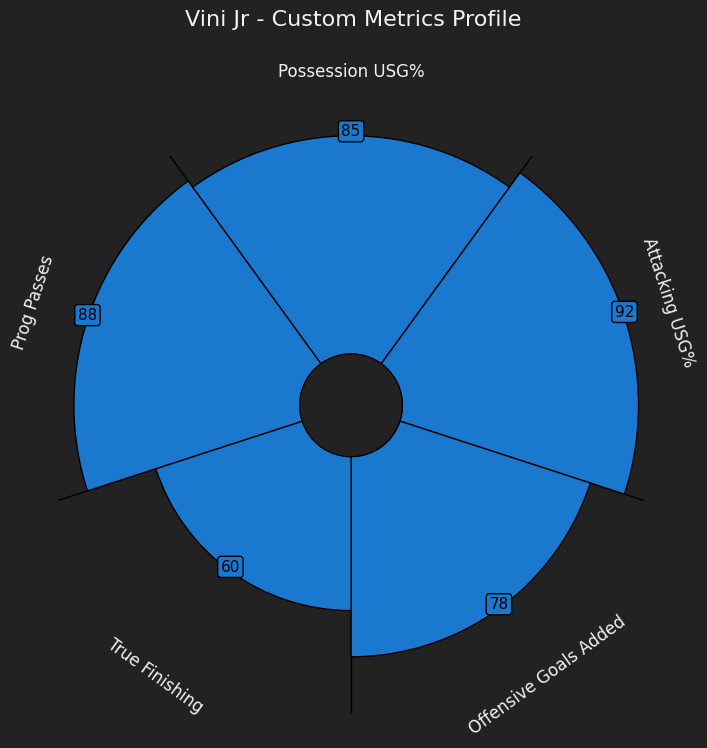

In [2]:
import matplotlib.pyplot as plt
from mplsoccer import PyPizza

# Example percentiles for a player (calculated from your custom metrics)
params = ["Possession USG%", "Attacking USG%", "Offensive Goals Added", "True Finishing", "Prog Passes"]
percentiles = [85, 92, 78, 60, 88] 

# Set up the PyPizza object
baker = PyPizza(
    params=params,                  # list of parameters
    background_color="#222222",     # dark mode background
    straight_line_color="#000000",
    straight_line_lw=1,
    last_circle_lw=0,
    other_circle_lw=0,
    inner_circle_size=20
)

# Plot the pizza
fig, ax = baker.make_pizza(
    percentiles,              # list of values
    figsize=(8, 8),           # adjust figsize according to your need
    param_location=110,       # where the parameters text is added
    kwargs_slices=dict(
        facecolor="#1A78CF", edgecolor="#000000", zorder=2, linewidth=1
    ),
    kwargs_params=dict(
        color="#F2F2F2", fontsize=12, va="center"
    ),
    kwargs_values=dict(
        color="#000000", fontsize=11, zorder=3,
        bbox=dict(edgecolor="#000000", facecolor="#1A78CF", boxstyle="round,pad=0.2", lw=1)
    )
)

# Add title
fig.text(0.515, 0.97, "Vini Jr - Custom Metrics Profile", size=16, ha="center", color="#F2F2F2")
plt.show()

Usage vs. Efficiency Scatter Plot

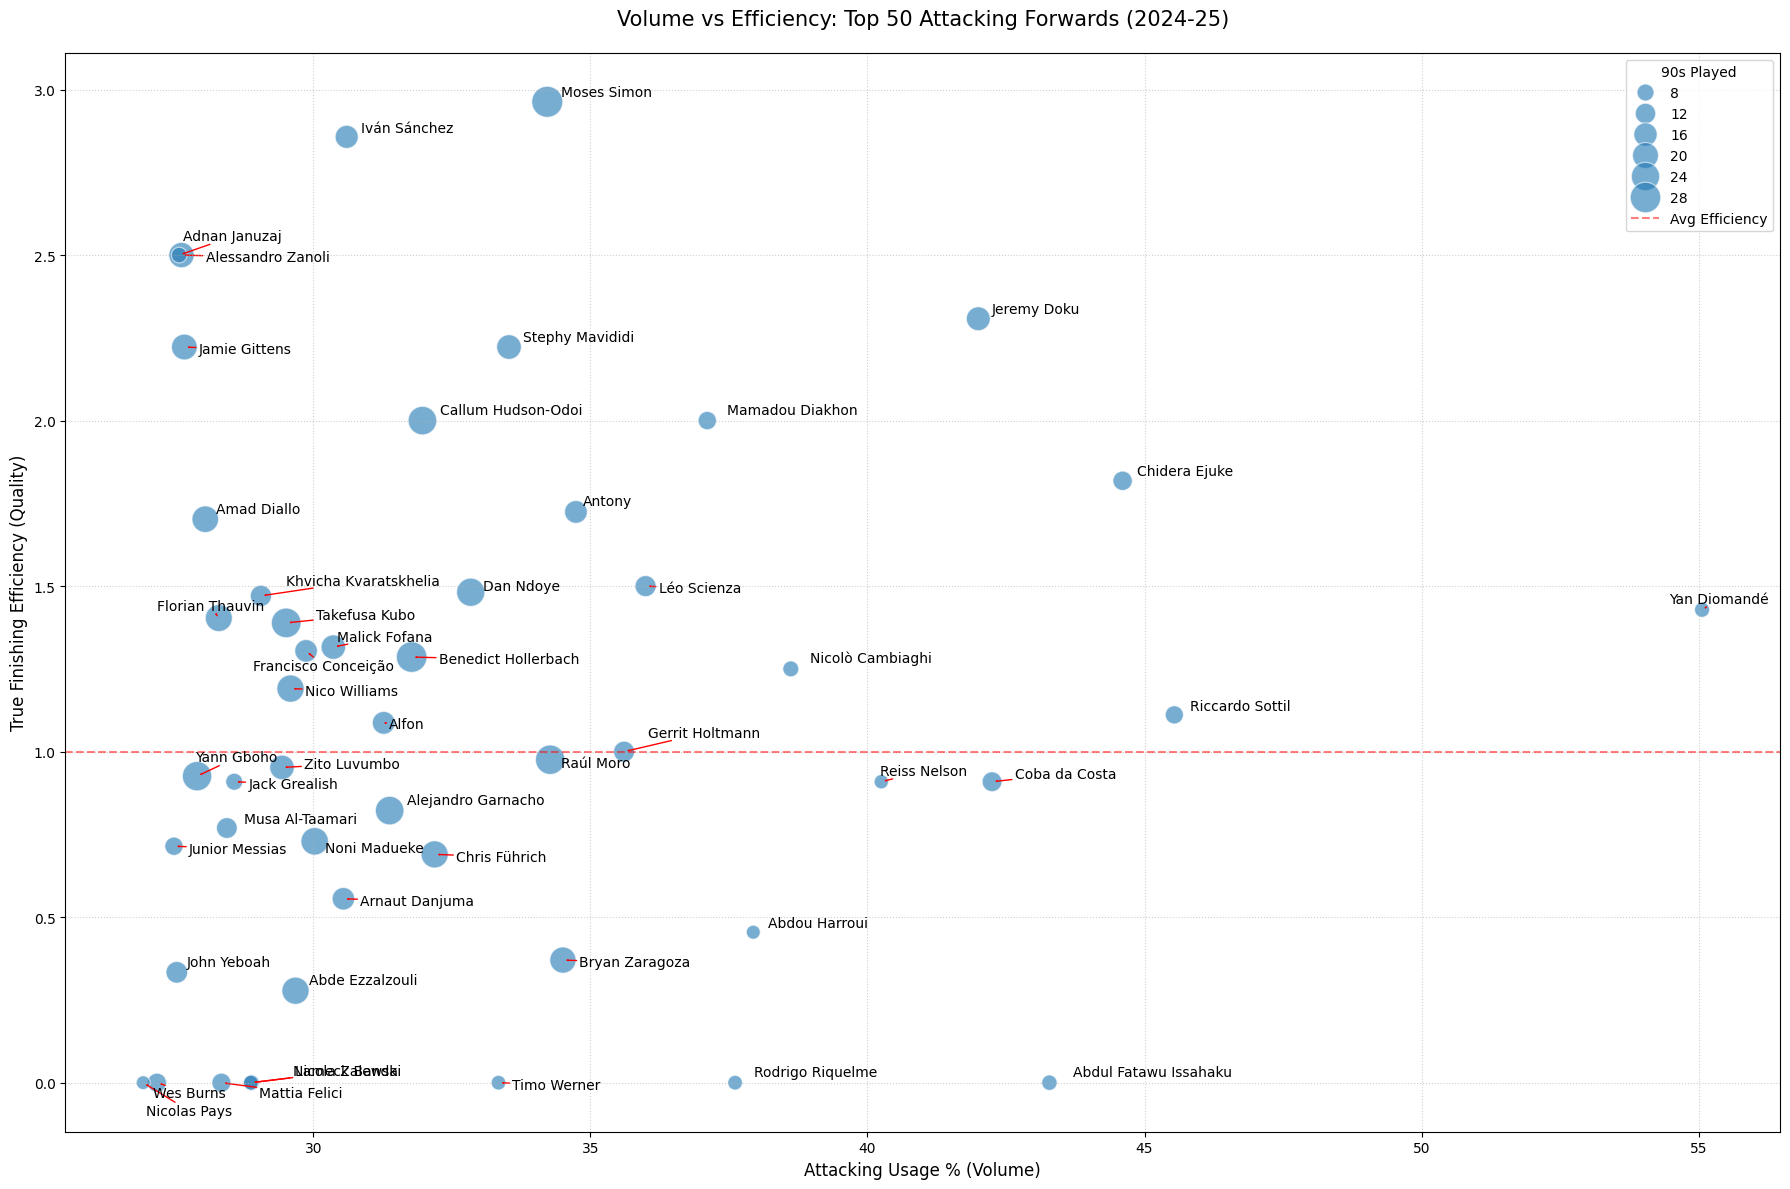

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from adjustText import adjust_text # used to automatically handle labels overlapping

comparison_df = pd.read_csv('data/adv_stats_inc/master_player_comparison.csv')

# 1. Filter for the top 50 players based on Attacking Usage
# We also filter for players with at least 5 '90s' to remove small-sample outliers
top_50_df = comparison_df[comparison_df['90s'] >= 5].nlargest(50, 'Attacking_USG_pct')

plt.figure(figsize=(18, 12))

# 2. Create the scatter plot using the filtered dataframe
sns.scatterplot(
    data=top_50_df, 
    x='Attacking_USG_pct', 
    y='TFE', 
    size='90s', 
    sizes=(100, 500), 
    alpha=0.6,
    edgecolor='white'
)

# Add labels for the top 50
texts = [plt.text(row['Attacking_USG_pct'], row['TFE'], row['Player']) for i, row in top_50_df.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# 4. Styling and Baselines
plt.title("Volume vs Efficiency: Top 50 Attacking Forwards (2024-25)", fontsize=15, pad=20)
plt.xlabel("Attacking Usage % (Volume)", fontsize=12)
plt.ylabel("True Finishing Efficiency (Quality)", fontsize=12)
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Avg Efficiency')
plt.legend(title='90s Played', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()